In [1]:
# # turn off numba njit
# import os
# os.environ["NUMBA_DISABLE_JIT"] = "1"

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7, Tcmb0=0.0, Neff=3.04, m_nu=None, Ob0=0.0)
from ler.lens_galaxy_population import LensGalaxyParameterDistribution

ler = LensGalaxyParameterDistribution(
    npool=6,
    directory="../interpolator_json",
    lens_functions=dict(
        cross_section='cross_section_epl_shear_njit',
        cross_section_based_sampler='rejection_sampler_partial',
        #cross_section_based_sampler='rejection_sampler_partial',
    ),
    lens_functions_params=dict(
        cross_section=dict(num_th=200, maginf=-100.0),
        #cross_section_based_sampler=dict(n_prop_factor=2),
        cross_section_based_sampler=dict(
            n_prop=10000,
            threshold_factor=1e-3,
            zs_min=0.5,
            zs_max=4.0,
            zl_min=0.0,
            zl_max=None,
            sigma_min=100.0,
            sigma_max=400.0,
            q_min=0.2,
            q_max=1.0,
            phi_min=0.0,
            phi_max=2 * np.pi,
            gamma_min=1.4,
            gamma_max=2.7,
            shear_min=-0.2,
            shear_max=0.2,
        ),
    ),
)

# 6m 48s


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/rayleigh_2.json
using ler availabl

## Gamma KS \(D\) comparisons

| Comparison (baseline → test) | n_prop (baseline) | threshold_factor (baseline) | n_prop (test) | threshold_factor (test) | KS D (gamma) |
|---|---:|---:|---:|---:|---:|
| lens_param0 → lens_param1 | 200 | 0.0 | 100 | 0.0 | 0.01702 |
| lens_param0 → lens_param2 | 200 | 0.0 | 100 | 1e-4 | 0.01580 |
| lens_param0 → lens_param3 | 200 | 0.0 | 100 | 1e-3 | 0.01712 |
| lens_param0 → lens_param4 | 200 | 0.0 | 200 | 1e-3 | 0.00606 |

In [43]:
lens_param = ler.sample_lens_parameters(10000);
# initialization njit takes 15s
# rejection sampling partial, n_prop=10000, threshold_factor=1e-3, size=10000, time=3m 4.4s
# importance sampling partial, n_prop=50, size=50000, time=14.2s
# importance sampling partial, n_prop=100, size=50000, time=30.2s

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [ ]:
# n_prop=200, threshold_factor=0.0,
# lens_param0 = lens_param.copy()

In [ ]:
# n_prop=100, threshold_factor=0.0,
# lens_param1 = lens_param.copy()

In [ ]:
# n_prop=100, threshold_factor=1e-4,
# lens_param2 = lens_param.copy()

In [ ]:
# n_prop=100, threshold_factor=1e-3,
# lens_param3 = lens_param.copy()

In [ ]:
# n_prop=200, threshold_factor=1e-3,
# lens_param4 = lens_param.copy()

In [12]:
import numpy as np

def KStest(
    lens_param1: dict,
    lens_param2: dict,
    *,
    keys=None,
    alternative: str = "two-sided",
    mode: str = "auto",
    nan_policy: str = "omit",
    return_pvalue: bool = True,
):
    """Two-sample KS tests for lens-parameter dictionaries.

    Parameters
    ----------
    lens_param1, lens_param2 : dict
        Dicts like the output of `ler.sample_lens_parameters`, mapping parameter
        names -> array-like samples.
    keys : iterable[str] | None
        Which keys to test. If None, uses the intersection of keys.
    alternative : str
        Passed to `scipy.stats.ks_2samp`.
    mode : str
        Passed to `scipy.stats.ks_2samp`.
    nan_policy : {'omit','propagate'}
        If 'omit', drops non-finite values before testing.
    return_pvalue : bool
        If True, return both KS statistic and p-value.

    Returns
    -------
    out : dict
        out[key] = {'D': <ks statistic>, 'pvalue': <pvalue>, 'n1': <int>, 'n2': <int>}
        If return_pvalue=False, 'pvalue' is omitted.
    """
    try:
        from scipy.stats import ks_2samp
    except Exception as e:
        raise ImportError(
            "KStest requires scipy. Install it (e.g. `pip install scipy`)."
        ) from e

    if keys is None:
        keys = sorted(set(lens_param1.keys()).intersection(lens_param2.keys()))

    out = {}
    for k in keys:
        x = np.asarray(lens_param1[k])
        y = np.asarray(lens_param2[k])

        if nan_policy == "omit":
            x = x[np.isfinite(x)]
            y = y[np.isfinite(y)]

        n1 = int(x.size)
        n2 = int(y.size)
        if n1 == 0 or n2 == 0:
            out[k] = {"D": np.nan, "pvalue": np.nan, "n1": n1, "n2": n2} if return_pvalue else {"D": np.nan, "n1": n1, "n2": n2}
            continue

        res = ks_2samp(x, y, alternative=alternative, mode=mode)
        if return_pvalue:
            out[k] = {"D": float(res.statistic), "pvalue": float(res.pvalue), "n1": n1, "n2": n2}
        else:
            out[k] = {"D": float(res.statistic), "n1": n1, "n2": n2}

    return out


In [36]:
KStest(lens_param0, lens_param3)
# lens_param0, lens_param4: gamma': {'D': 0.006060000000000065,
# lens_param0, lens_param1: 'gamma': {'D': 0.017020000000000035,
# lens_param0, lens_param2: 'gamma': {'D': 0.01580000000000001,
# lens_param0, lens_param3: 'gamma': {'D': 0.017120000000000024,

{'dec': {'D': 0.006780000000000008,
  'pvalue': 0.19972875117940625,
  'n1': 50000,
  'n2': 50000},
 'gamma': {'D': 0.017120000000000024,
  'pvalue': 8.535928324440913e-07,
  'n1': 50000,
  'n2': 50000},
 'gamma1': {'D': 0.012140000000000012,
  'pvalue': 0.0012506368835071995,
  'n1': 50000,
  'n2': 50000},
 'gamma2': {'D': 0.01257999999999998,
  'pvalue': 0.0007257769420411027,
  'n1': 50000,
  'n2': 50000},
 'geocent_time': {'D': 0.0040999999999999925,
  'pvalue': 0.7930696291258396,
  'n1': 50000,
  'n2': 50000},
 'luminosity_distance': {'D': 0.0037800000000000056,
  'pvalue': 0.8659726587393721,
  'n1': 50000,
  'n2': 50000},
 'mass_1': {'D': 0.0040799999999999725,
  'pvalue': 0.7979423493458295,
  'n1': 50000,
  'n2': 50000},
 'mass_1_source': {'D': 0.007780000000000009,
  'pvalue': 0.09646398385168586,
  'n1': 50000,
  'n2': 50000},
 'mass_2': {'D': 0.006059999999999954,
  'pvalue': 0.31629443907033783,
  'n1': 50000,
  'n2': 50000},
 'mass_2_source': {'D': 0.00763999999999998,
 

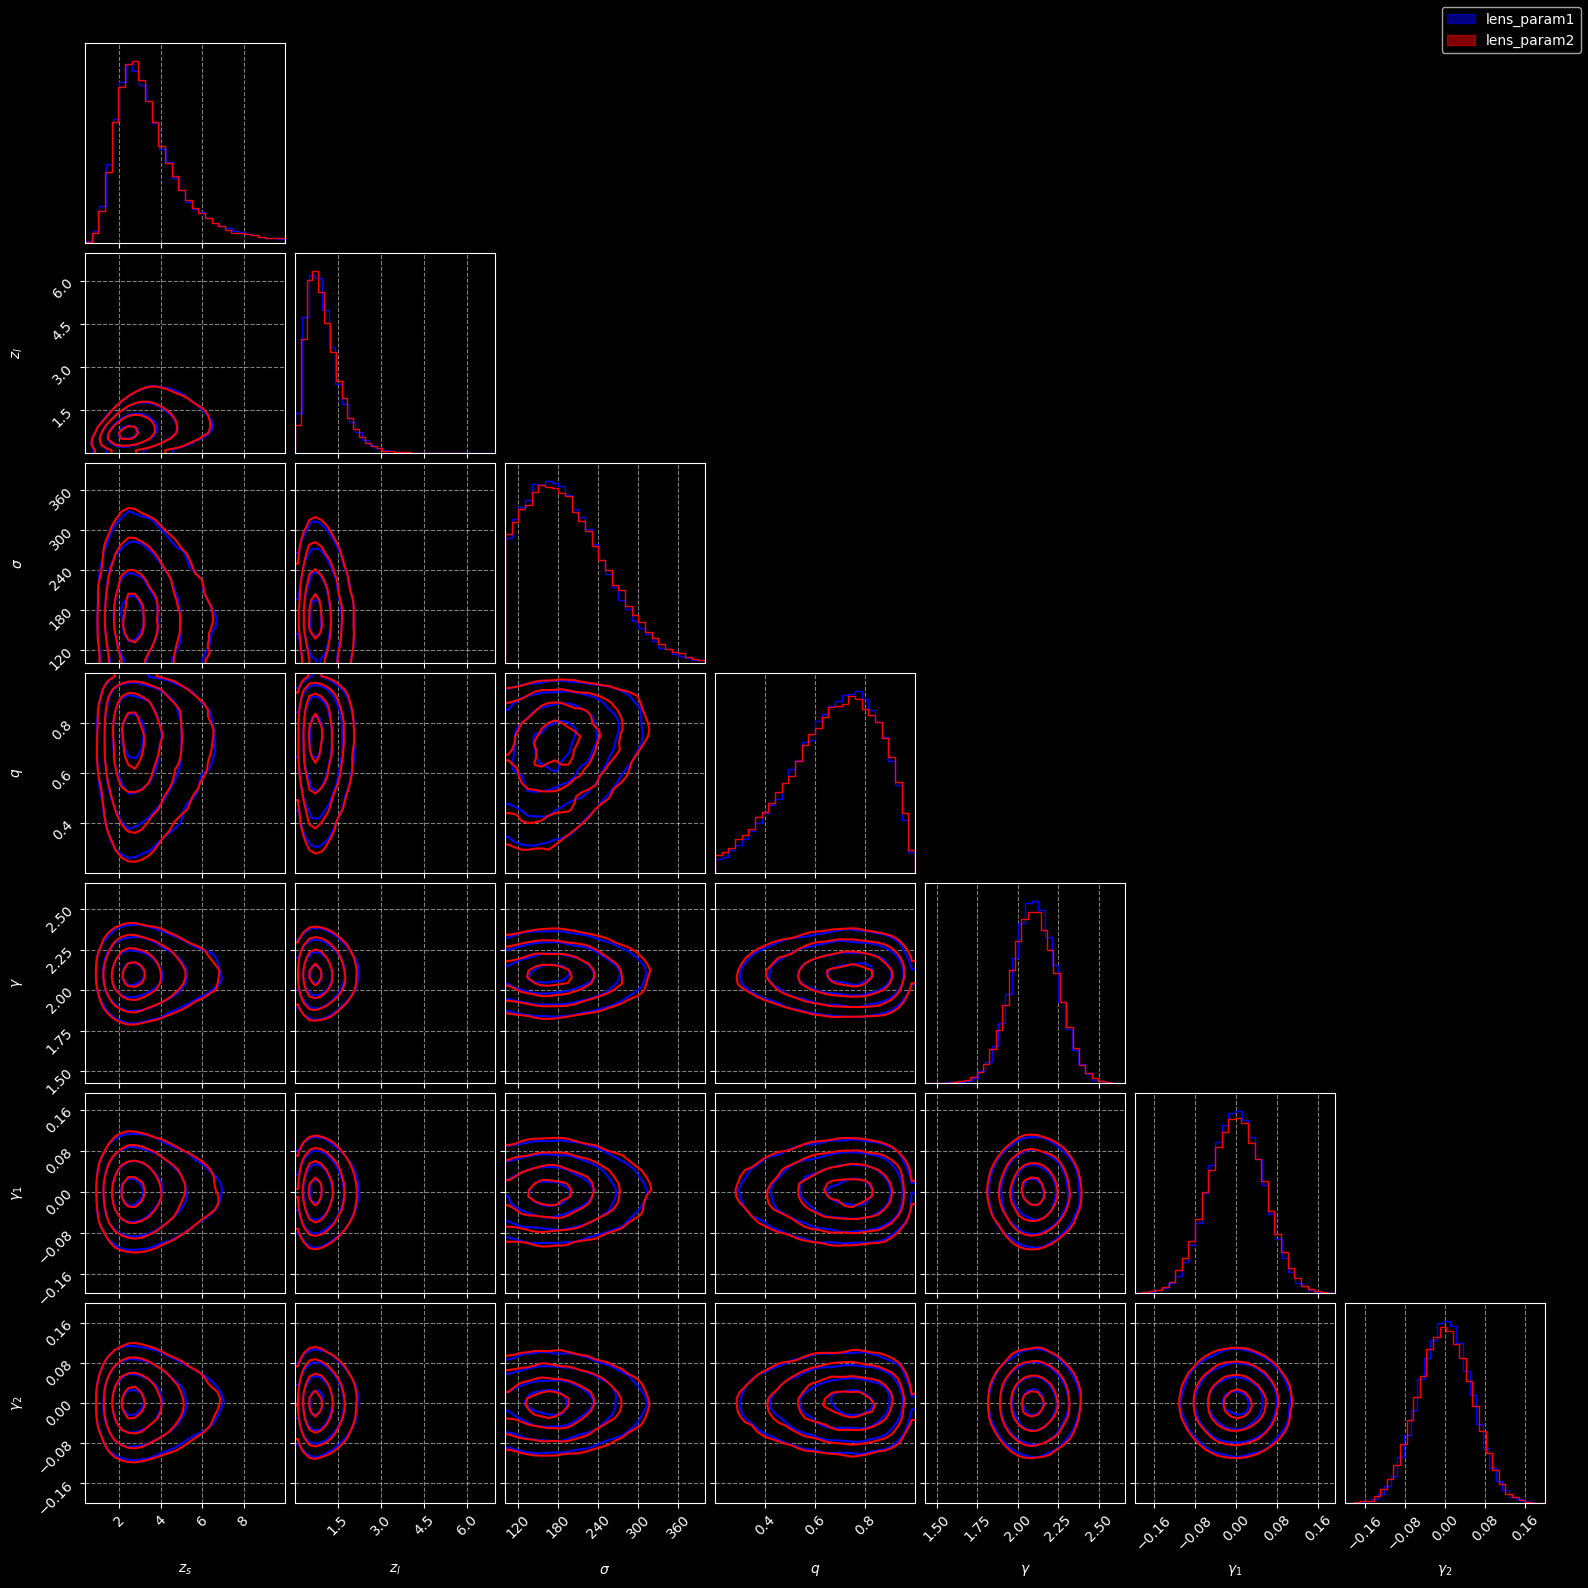

In [39]:
import corner
lens_param = lens_param0
samples1 = np.vstack([lens_param['zs'], lens_param['zl'], lens_param['sigma'], lens_param['q'], lens_param['gamma'], lens_param['gamma1'], lens_param['gamma2']]).T
figure = corner.corner(
    samples1, 
    labels=[r"$z_s$", r"$z_l$", r"$\sigma$", r"$q$", r"$\gamma$", r"$\gamma_1$", r"$\gamma_2$"],
    color='blue',
    bins=30,
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)
lens_param = lens_param2
samples2 = np.vstack([lens_param['zs'], lens_param['zl'], lens_param['sigma'], lens_param['q'], lens_param['gamma'], lens_param['gamma1'], lens_param['gamma2']]).T
# add corner plot on the same figure
corner.corner(
    samples2, 
    labels=[r"$z_s$", r"$z_l$", r"$\sigma$", r"$q$", r"$\gamma$", r"$\gamma_1$", r"$\gamma_2$"], 
    color='red', 
    bins=30, 
    alpha=0.5, 
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8, 
    hist_kwargs={'density': True}, 
    fig=figure
)

import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color="blue", alpha=0.5, label="lens_param1"),
    mpatches.Patch(color="red", alpha=0.5, label="lens_param2"),
]
figure.legend(handles=handles, loc="upper right", frameon=True)
figure

for ax in figure.get_axes():
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

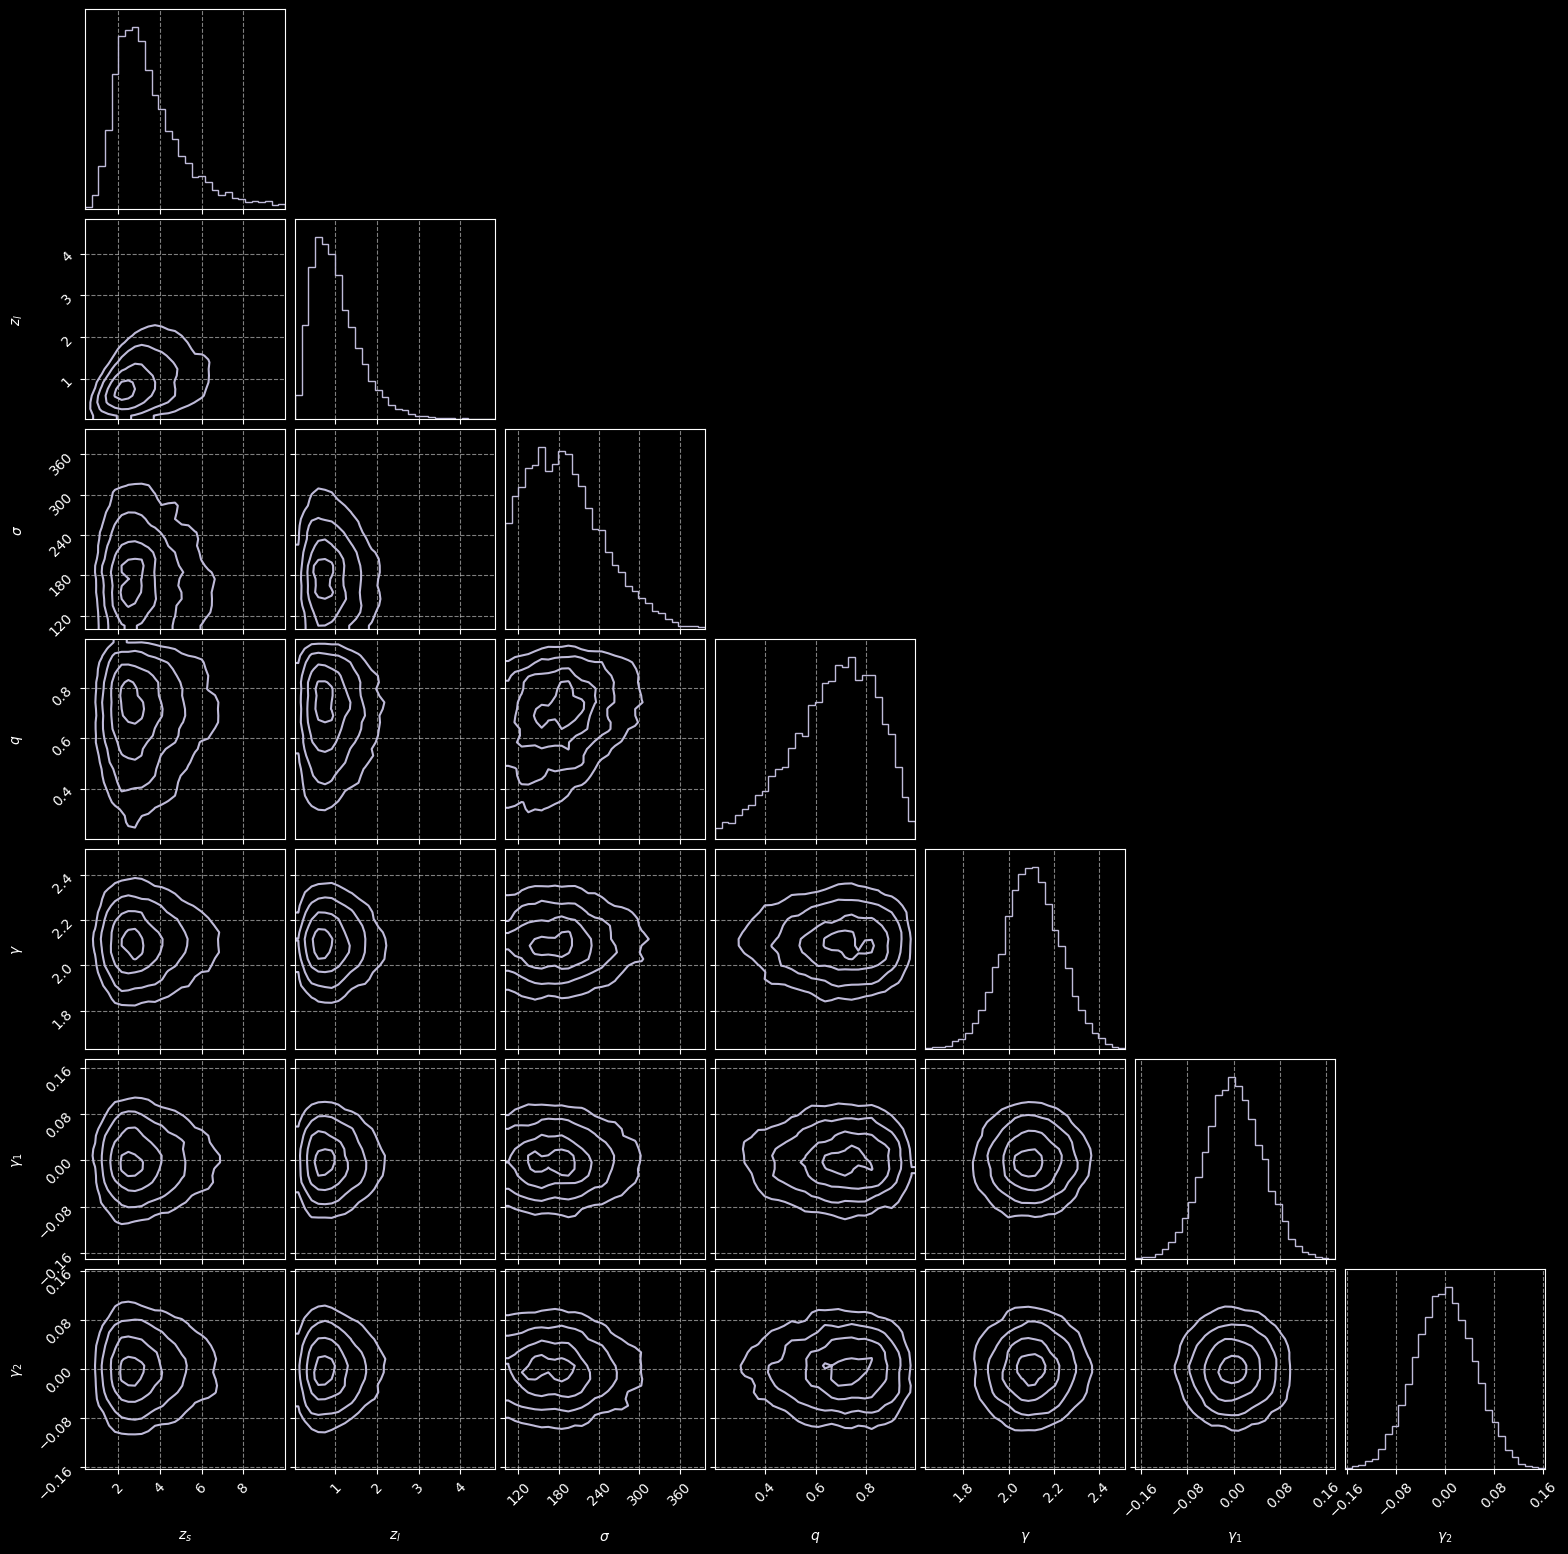

In [44]:
import corner
samples = np.vstack([lens_param['zs'], lens_param['zl'], lens_param['sigma'], lens_param['q'], lens_param['gamma'], lens_param['gamma1'], lens_param['gamma2']]).T
figure = corner.corner(
    samples, 
    labels=[r"$z_s$", r"$z_l$", r"$\sigma$", r"$q$", r"$\gamma$", r"$\gamma_1$", r"$\gamma_2$"],
    color='C2',
    bins=30,
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

for ax in figure.get_axes():
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

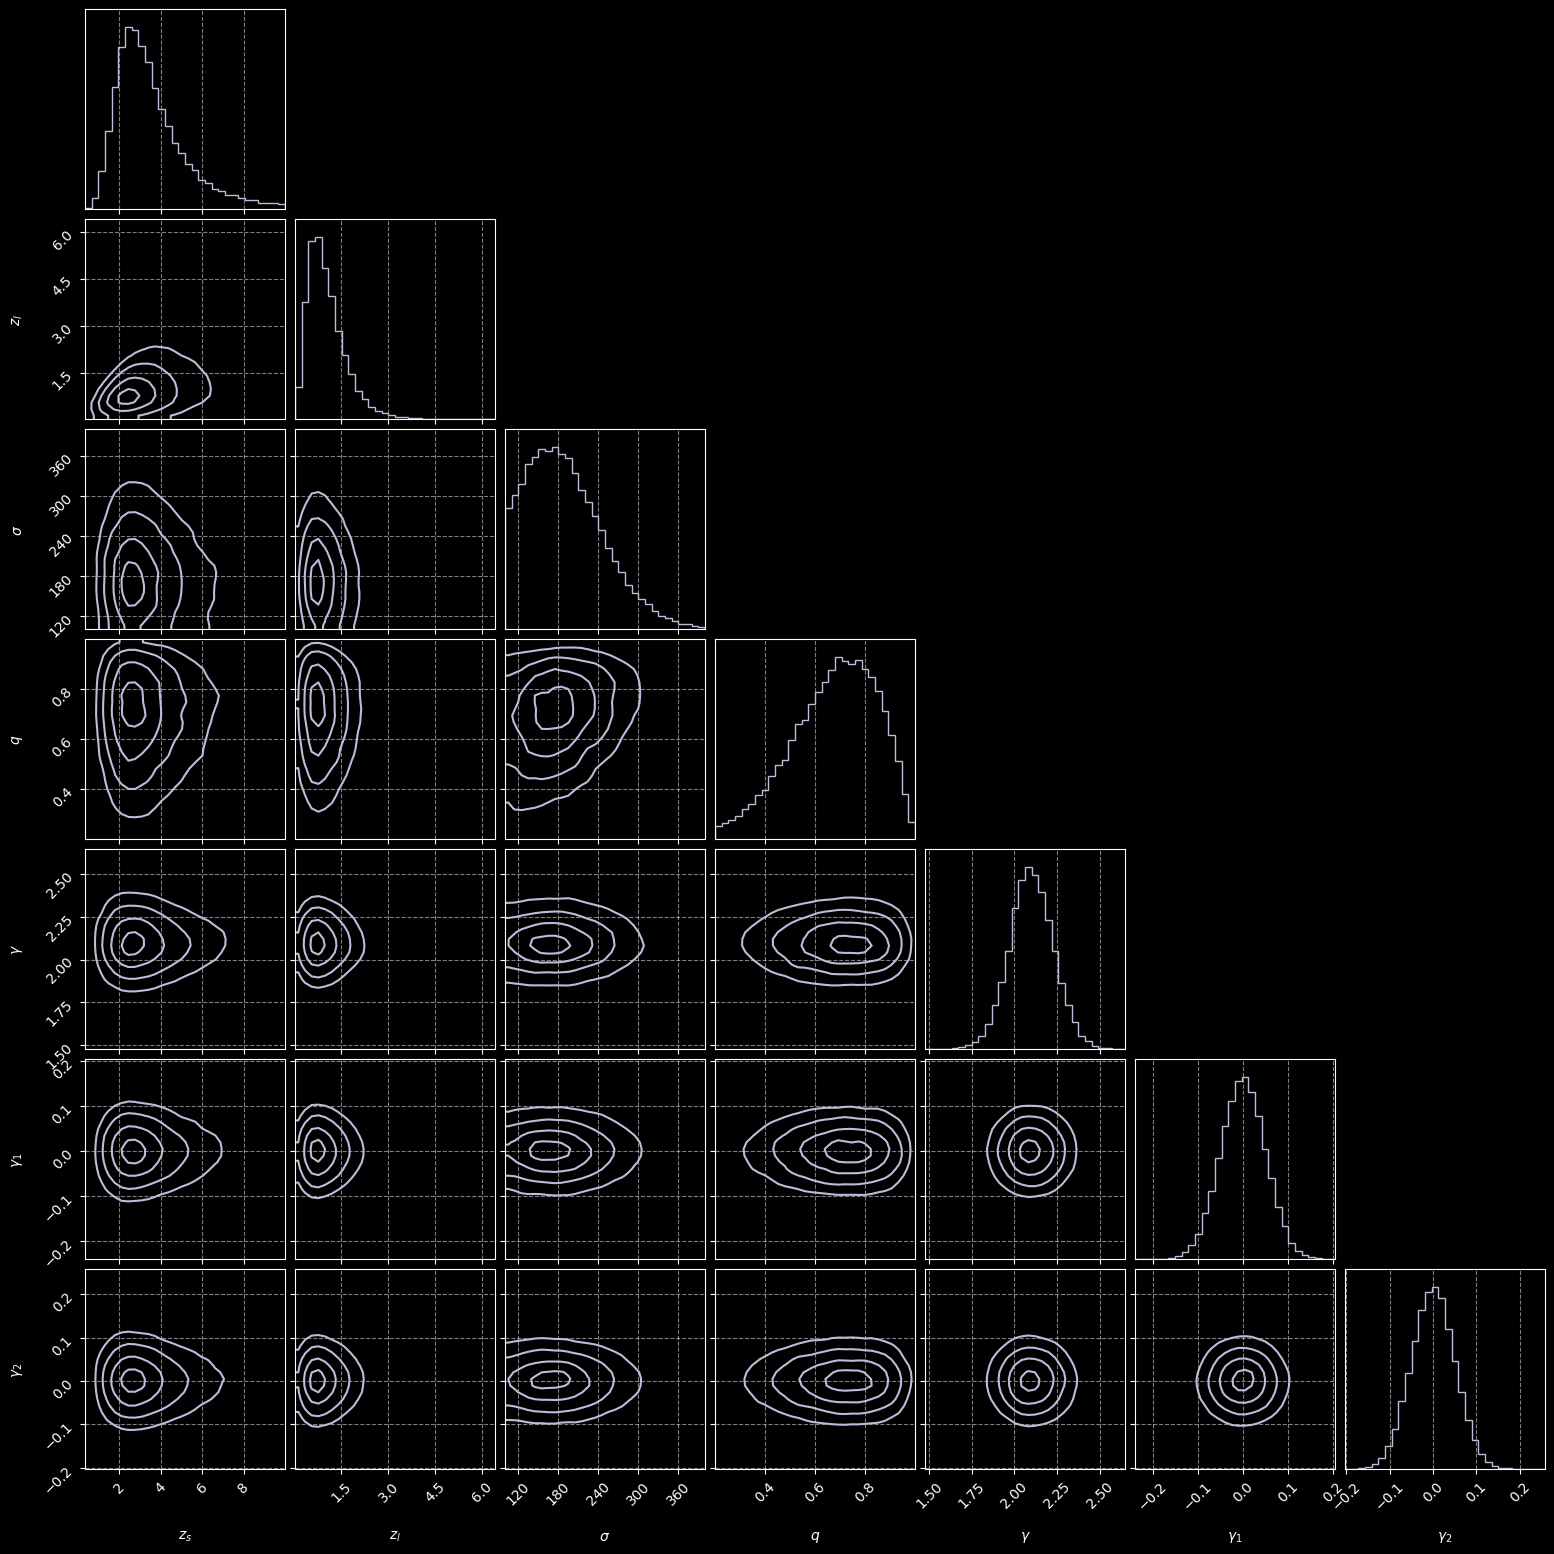

In [19]:
import corner
samples = np.vstack([lens_param['zs'], lens_param['zl'], lens_param['sigma'], lens_param['q'], lens_param['gamma'], lens_param['gamma1'], lens_param['gamma2']]).T
figure = corner.corner(
    samples, 
    labels=[r"$z_s$", r"$z_l$", r"$\sigma$", r"$q$", r"$\gamma$", r"$\gamma_1$", r"$\gamma_2$"],
    color='C2',
    bins=30,
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

for ax in figure.get_axes():
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [7]:
50002//4

12500

In [9]:
12500*4

50000

In [10]:
[5002] * 4

[5002, 5002, 5002, 5002]

In [13]:
size = 50002
npool = 4
size_i = size // npool 
size_list = [size_i] * npool
size_list[npool - 1] += size % npool  # Add remainder to last pool
idx_range = [[i * size_i, (i + 1) * size_i-1] for i in range(npool)]
idx_range[npool - 1][1] += size % npool  # Add remainder to last pool
idx_range

[[0, 12499], [12500, 24999], [25000, 37499], [37500, 50001]]

In [20]:
import numpy as np
np.random.random(1)

array([0.03613257])

In [21]:
np.append([1,2], [2,3])

array([1, 2, 2, 3])

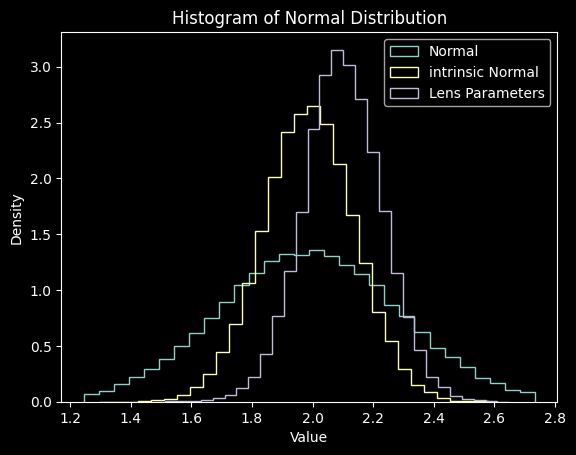

In [37]:
from ler.gw_source_population import truncated_normal_rvs
plt.hist(truncated_normal_rvs(size=50000, mu=1.99, sigma=0.149*2, x_min=1.99-0.149*5, x_max=1.99+0.149*5), bins=30, density=True, histtype='step', label='Normal')
plt.hist(truncated_normal_rvs(size=50000, mu=1.99, sigma=0.149, x_min=-np.inf, x_max=np.inf), bins=30, density=True, histtype='step', label='intrinsic Normal')
plt.hist(lens_param['gamma'], bins=30, density=True, histtype='step', label='Lens Parameters')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram of Normal Distribution')
plt.legend()
plt.show()

In [2]:
size = 1000000

# Sample source redshift with strong lensing weighting
zs_samples = ler.zs_sl(size)
# zs_samples = np.ones(size) * 10.0

# Sample lens redshift conditioned on source redshift
zl_samples = ler.lens_redshift_sl.rvs(size, zs_samples)
# zl_samples = np.ones(size) * 2.0

# Sample other lens parameters using cross-section based sampler
sigma_samples = ler.velocity_dispersion_sl.rvs(size, zl_samples)

In [ ]:
# Add a legend to an overlaid corner plot (run after creating `figure`)
import matplotlib.patches as mpatches

handles = [
    mpatches.Patch(color="C0", alpha=0.5, label="lens_param1"),
    mpatches.Patch(color="C1", alpha=0.5, label="lens_param2"),
]
figure.legend(handles=handles, loc="upper right", frameon=True)
figure


ValueError: It looks like the parameter(s) in column(s) 0, 1 have no dynamic range. Please provide a `range` argument.

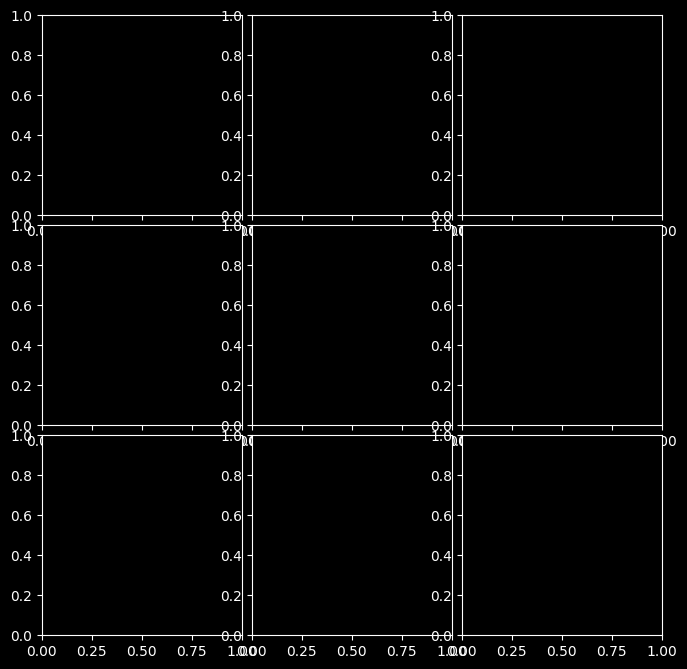

In [14]:
import corner
samples = np.vstack([zs_samples, zl_samples, sigma_samples]).T
figure = corner.corner(
    samples, 
    labels=[r"$z_s$", r"$z_l$", r"$\sigma$"],
    color='C2',
    bins=50,
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    smooth=0.8,
    hist_kwargs={'density': True}
)

for ax in figure.get_axes():
    ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

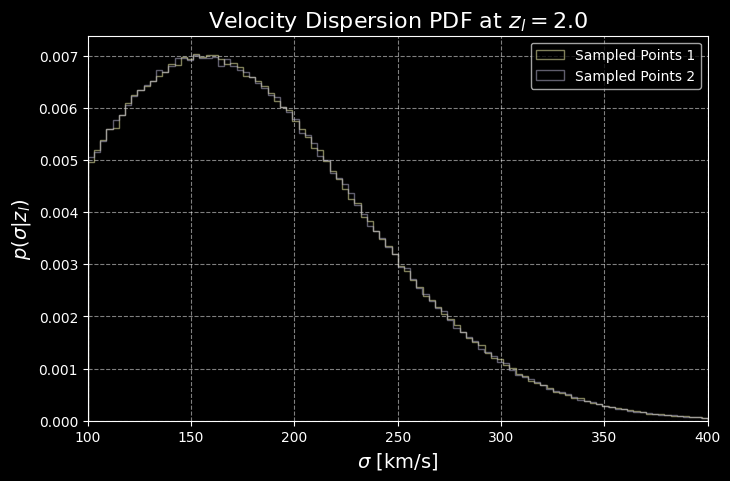

In [21]:
from ler.utils import generate_mixed_grid

# plot sigma_sl pdf
size = 1000
zl_ = 2.0
zl = np.ones(size) * zl_
sigma = np.linspace(100, 400, size)

sigma_samples2 = ler.velocity_dispersion_sl.rvs(1000000, np.ones(1000000) * zl_)

pdf = ler.velocity_dispersion_sl.pdf(sigma, zl)
# pdf_pts = ler.velocity_dispersion_sl.pdf(generate_mixed_grid(100, 400, 48), zl)

plt.figure(figsize=(8, 5))
# plt.plot(sigma, pdf, color='C0', label='PDF from Interpolator')
plt.hist(sigma_samples, bins=100, density=True, alpha=0.5, color='C1', histtype='step', label='Sampled Points 1')
plt.hist(sigma_samples2, bins=100, density=True, alpha=0.5, color='C2', histtype='step', label='Sampled Points 2')
# plt.scatter(generate_mixed_grid(100, 400, 48), pdf_pts, color='C2', marker='x', label='Interpolator Points')
plt.xlabel(r'$\sigma$ [km/s]', fontsize=14)
plt.ylabel(r'$p(\sigma | z_l)$', fontsize=14)
plt.title(f'Velocity Dispersion PDF at $z_l={zl_}$', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(100, 400)
plt.legend()
plt.show()

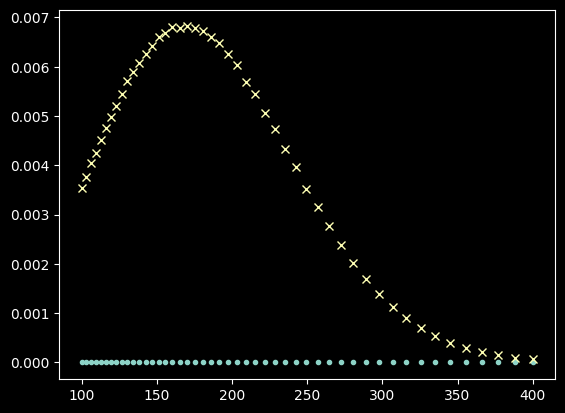

In [18]:
pts = np.geomspace(100, 400, 48)
idx = pts>=100
pts_ = pts[idx]
pdf_pts_ = ler.velocity_dispersion_sl.pdf(pts_, np.ones_like(pts_)*0.5)
plt.plot(pts, np.zeros_like(pts), '.')
plt.plot(pts_, pdf_pts_, 'x')
plt.show()

In [ ]:
import numpy as np

def KStest(
    lens_param1: dict,
    lens_param2: dict,
    *,
    keys=None,
    alternative: str = "two-sided",
    mode: str = "auto",
    nan_policy: str = "omit",
    return_pvalue: bool = True,
):
    """Two-sample KS tests for lens-parameter dictionaries.

    Parameters
    ----------
    lens_param1, lens_param2 : dict
        Dicts like the output of `ler.sample_lens_parameters`, mapping parameter
        names -> array-like samples.
    keys : iterable[str] | None
        Which keys to test. If None, uses the intersection of keys.
    alternative : str
        Passed to `scipy.stats.ks_2samp`.
    mode : str
        Passed to `scipy.stats.ks_2samp`.
    nan_policy : {'omit','propagate'}
        If 'omit', drops non-finite values before testing.
    return_pvalue : bool
        If True, return both KS statistic and p-value.

    Returns
    -------
    out : dict
        out[key] = {'D': <ks statistic>, 'pvalue': <pvalue>, 'n1': <int>, 'n2': <int>}
        If return_pvalue=False, 'pvalue' is omitted.
    """
    try:
        from scipy.stats import ks_2samp
    except Exception as e:
        raise ImportError(
            "KStest requires scipy. Install it (e.g. `pip install scipy`)."
        ) from e

    if keys is None:
        keys = sorted(set(lens_param1.keys()).intersection(lens_param2.keys()))

    out = {}
    for k in keys:
        x = np.asarray(lens_param1[k])
        y = np.asarray(lens_param2[k])

        if nan_policy == "omit":
            x = x[np.isfinite(x)]
            y = y[np.isfinite(y)]

        n1 = int(x.size)
        n2 = int(y.size)
        if n1 == 0 or n2 == 0:
            out[k] = {"D": np.nan, "pvalue": np.nan, "n1": n1, "n2": n2} if return_pvalue else {"D": np.nan, "n1": n1, "n2": n2}
            continue

        res = ks_2samp(x, y, alternative=alternative, mode=mode)
        if return_pvalue:
            out[k] = {"D": float(res.statistic), "pvalue": float(res.pvalue), "n1": n1, "n2": n2}
        else:
            out[k] = {"D": float(res.statistic), "n1": n1, "n2": n2}

    return out
